In [1]:
# Imports
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import DatasetFolder
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import numpy as np
import gc

from generative.networks.nets import DiffusionModelUNet
from generative.networks.schedulers import DDPMScheduler, DDIMScheduler
from generative.inferers import DiffusionInferer
from torch.amp import autocast, GradScaler

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {device}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

🖥️  Device: cuda
🎮 GPU: NVIDIA GeForce RTX 4060 Laptop GPU
💾 VRAM: 8.59 GB


c:\Users\R K Raman\AppData\Local\Programs\Python\Python311\Lib\site-packages\generative\networks\layers\vector_quantizer.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)
c:\Users\R K Raman\AppData\Local\Programs\Python\Python311\Lib\site-packages\generative\networks\layers\vector_quantizer.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


In [2]:
# ============================================
# CONFIGURATION - Brain CT
# ============================================
IMAGE_SIZE = 64           # Reduced for memory efficiency
BATCH_SIZE = 8            # Smaller batch for GPU memory
NUM_EPOCHS = 100
LEARNING_RATE = 1e-4
NUM_TRAIN_TIMESTEPS = 1000

# Paths
DATA_DIR = Path(r"c:\Pranav Aditya\MP01")
BRAIN_CT_DIR = DATA_DIR / "extracted_data" / "CT SCANS" / "Computed Tomography (CT) of the Brain" / "Computed Tomography (CT) of the Brain" / "data"
MODEL_SAVE_PATH = DATA_DIR / "brain_ct_model.pth"

print(f"📁 Dataset: {BRAIN_CT_DIR}")
print(f"💾 Model will be saved to: {MODEL_SAVE_PATH}")
print(f"🖼️  Config: {IMAGE_SIZE}x{IMAGE_SIZE} RGB, Batch {BATCH_SIZE}")

📁 Dataset: c:\Pranav Aditya\MP01\extracted_data\CT SCANS\Computed Tomography (CT) of the Brain\Computed Tomography (CT) of the Brain\data
💾 Model will be saved to: c:\Pranav Aditya\MP01\brain_ct_model.pth
🖼️  Config: 64x64 RGB, Batch 8


In [3]:
# ============================================
# DATA LOADING - RGB COLORED IMAGES
# ============================================
IMG_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif')

# Transforms for RGB images
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load dataset
dataset = DatasetFolder(
    root=str(BRAIN_CT_DIR),
    loader=lambda p: Image.open(p).convert('RGB'),
    extensions=IMG_EXTENSIONS,
    transform=train_transforms
)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True
)

print(f"✅ Loaded {len(dataset)} images at {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"📊 Classes: {dataset.classes}")
print(f"📦 Batches per epoch: {len(dataloader)}")

✅ Loaded 3367 images at 64x64
📊 Classes: ['aneurysm', 'cancer', 'tumor']
📦 Batches per epoch: 420


In [ ]:
# ============================================
# VISUALIZE SAMPLE IMAGES
# ============================================
sample_batch = next(iter(dataloader))
sample_images = sample_batch[0][:8]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    img = sample_images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5)  # Denormalize
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Sample {i+1}')

plt.suptitle('🧠 Brain CT Dataset - Sample Images (RGB)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
# ============================================
# CREATE MODEL FOR 8GB VRAM
# ============================================
# Clear memory
gc.collect()
torch.cuda.empty_cache()

print(f"💾 GPU before model: {torch.cuda.memory_allocated()/1e9:.2f} GB")

model = DiffusionModelUNet(
    spatial_dims=2,
    in_channels=3,
    out_channels=3,
    num_channels=(64, 128, 256, 256),
    attention_levels=(False, False, True, True),
    num_res_blocks=2,
    num_head_channels=64,
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"🧠 Model Parameters: {num_params:,}")

scheduler = DDPMScheduler(
    num_train_timesteps=NUM_TRAIN_TIMESTEPS,
    schedule="linear_beta",
)
inferer = DiffusionInferer(scheduler)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print(f"✅ Model created!")
print(f"💾 GPU after model: {torch.cuda.memory_allocated()/1e9:.2f} GB")

💾 GPU before model: 0.00 GB
🧠 Model Parameters: 26,623,363
✅ Model created!
💾 GPU after model: 0.11 GB


🧠 BRAIN CT MODEL TRAINING
📊 Dataset: 3367 images
🖼️  Resolution: 64x64 RGB
📦 Batch size: 8
🔄 Epochs: 100
🖥️  Device: cuda
⚡ Using Mixed Precision (FP16)


Epoch 1/100: 100%|██████████| 420/420 [01:35<00:00,  4.41it/s, loss=0.0172]


Epoch 1/100 | Loss: 0.188863 | Best: 0.188863


Epoch 2/100: 100%|██████████| 420/420 [00:59<00:00,  7.00it/s, loss=0.0472]


Epoch 2/100 | Loss: 0.038379 | Best: 0.038379


...

Epoch 23/100 | Loss: 0.018252 | Best: 0.016676


Epoch 24/100: 100%|██████████| 420/420 [00:56<00:00,  7.45it/s, loss=0.0019]


Epoch 24/100 | Loss: 0.018616 | Best: 0.016676


Epoch 25/100: 100%|██████████| 420/420 [01:03<00:00,  6.60it/s, loss=0.0082]


Epoch 25/100 | Loss: 0.016924 | Best: 0.016676


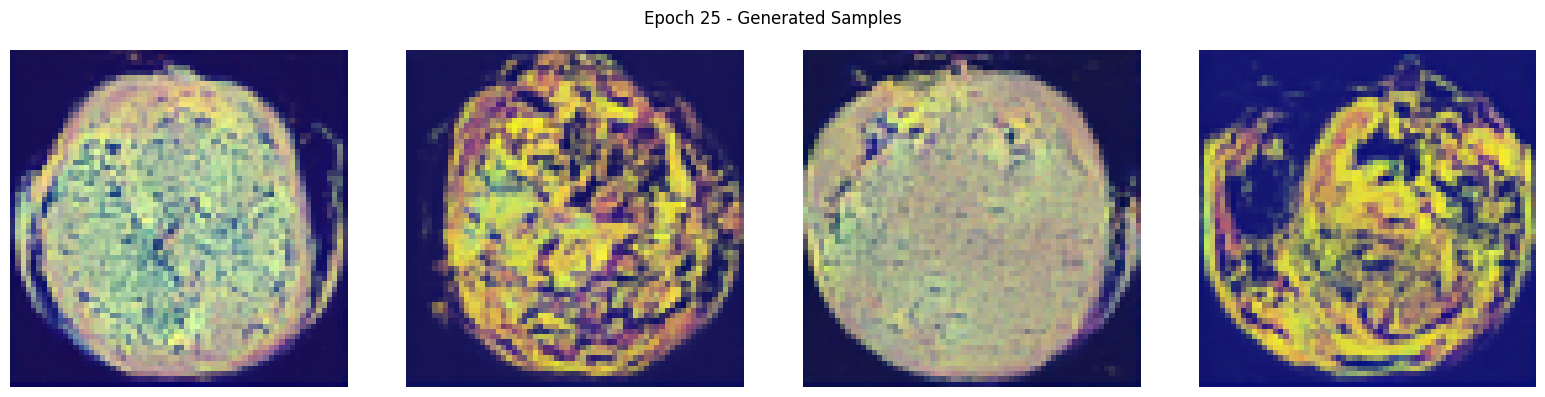

Epoch 26/100: 100%|██████████| 420/420 [01:07<00:00,  6.18it/s, loss=0.0094]


Epoch 26/100 | Loss: 0.018033 | Best: 0.016676


Epoch 27/100: 100%|██████████| 420/420 [01:04<00:00,  6.47it/s, loss=0.0090]


Epoch 27/100 | Loss: 0.018094 | Best: 0.016676


Epoch 28/100: 100%|██████████| 420/420 [01:05<00:00,  6.40it/s, loss=0.0115]


...

Epoch 48/100 | Loss: 0.014212 | Best: 0.013196


Epoch 49/100: 100%|██████████| 420/420 [01:05<00:00,  6.40it/s, loss=0.0052]


Epoch 49/100 | Loss: 0.013894 | Best: 0.013196


Epoch 50/100: 100%|██████████| 420/420 [01:04<00:00,  6.49it/s, loss=0.0250]


Epoch 50/100 | Loss: 0.014269 | Best: 0.013196


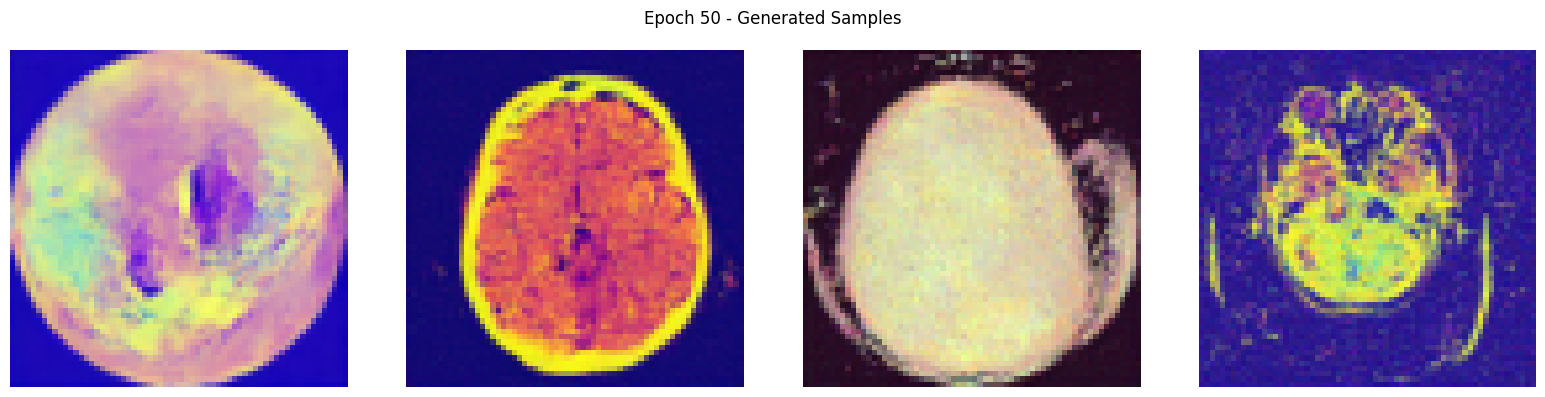

Epoch 51/100: 100%|██████████| 420/420 [01:03<00:00,  6.65it/s, loss=0.0149]


Epoch 51/100 | Loss: 0.014126 | Best: 0.013196


Epoch 52/100: 100%|██████████| 420/420 [01:05<00:00,  6.44it/s, loss=0.0039]


Epoch 52/100 | Loss: 0.012609 | Best: 0.012609


Epoch 53/100: 100%|██████████| 420/420 [01:02<00:00,  6.74it/s, loss=0.0031]


...

Epoch 73/100 | Loss: 0.011507 | Best: 0.011028


Epoch 74/100: 100%|██████████| 420/420 [00:56<00:00,  7.49it/s, loss=0.0174]


Epoch 74/100 | Loss: 0.012351 | Best: 0.011028


Epoch 75/100: 100%|██████████| 420/420 [00:55<00:00,  7.51it/s, loss=0.0051]


Epoch 75/100 | Loss: 0.011217 | Best: 0.011028


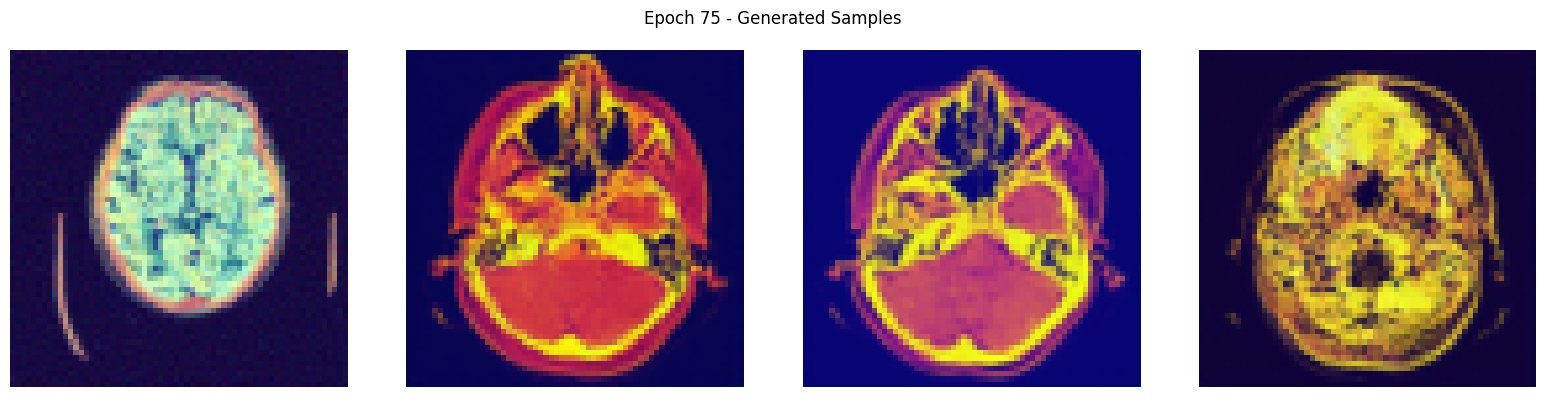

Epoch 76/100: 100%|██████████| 420/420 [00:55<00:00,  7.56it/s, loss=0.0104]


Epoch 76/100 | Loss: 0.009858 | Best: 0.009858


Epoch 77/100: 100%|██████████| 420/420 [00:56<00:00,  7.48it/s, loss=0.0075]


Epoch 77/100 | Loss: 0.011035 | Best: 0.009858


Epoch 78/100: 100%|██████████| 420/420 [00:54<00:00,  7.67it/s, loss=0.0144]


...

Epoch 98/100 | Loss: 0.010337 | Best: 0.009858


Epoch 99/100: 100%|██████████| 420/420 [00:53<00:00,  7.86it/s, loss=0.0040]


Epoch 99/100 | Loss: 0.010633 | Best: 0.009858


Epoch 100/100: 100%|██████████| 420/420 [00:54<00:00,  7.72it/s, loss=0.0033]


Epoch 100/100 | Loss: 0.011028 | Best: 0.009858


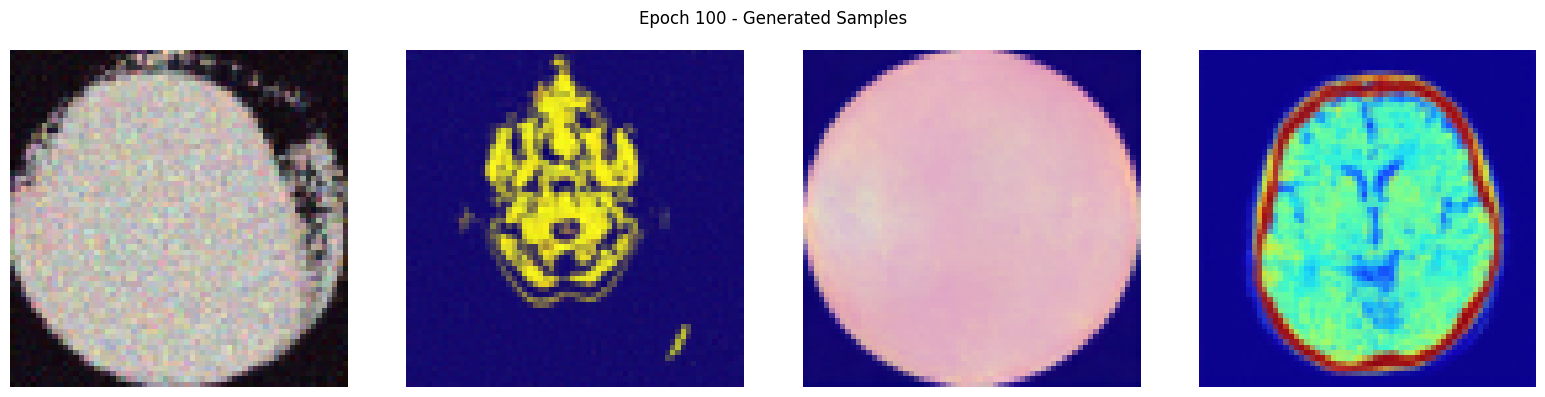


✅ TRAINING COMPLETE!
💾 Model saved: c:\Pranav Aditya\MP01\brain_ct_model.pth
📉 Best Loss: 0.009858


In [5]:
# ============================================
# TRAINING LOOP - WITH MIXED PRECISION
# ============================================
print("="*60)
print("🧠 BRAIN CT MODEL TRAINING")
print("="*60)
print(f"📊 Dataset: {len(dataset)} images")
print(f"🖼️  Resolution: {IMAGE_SIZE}x{IMAGE_SIZE} RGB")
print(f"📦 Batch size: {BATCH_SIZE}")
print(f"🔄 Epochs: {NUM_EPOCHS}")
print(f"🖥️  Device: {device}")
print(f"⚡ Using Mixed Precision (FP16)")
print("="*60)

scaler = GradScaler('cuda')
losses = []
best_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for batch in pbar:
        images = batch[0].to(device)
        
        optimizer.zero_grad()
        
        timesteps = torch.randint(0, NUM_TRAIN_TIMESTEPS, (images.shape[0],)).to(device)
        noise = torch.randn_like(images)
        noisy_images = scheduler.add_noise(images, noise, timesteps)
        
        with autocast('cuda'):
            noise_pred = model(noisy_images, timesteps=timesteps)
            loss = nn.functional.mse_loss(noise_pred, noise)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    epoch_loss = total_loss / len(dataloader)
    losses.append(epoch_loss)
    lr_scheduler.step()
    
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {epoch_loss:.6f} | Best: {best_loss:.6f}")
    
    # Generate samples every 25 epochs
    if (epoch + 1) % 25 == 0:
        model.eval()
        gen_scheduler = DDIMScheduler(num_train_timesteps=NUM_TRAIN_TIMESTEPS, schedule="linear_beta")
        gen_scheduler.set_timesteps(50)
        
        with torch.no_grad():
            noise = torch.randn(4, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
            image = noise
            for t in gen_scheduler.timesteps:
                with autocast('cuda'):
                    out = model(image, timesteps=torch.tensor([t]*4).to(device))
                image, _ = gen_scheduler.step(out, t, image)
            samples = image.cpu()
        
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        for i, ax in enumerate(axes):
            img = samples[i].permute(1, 2, 0).numpy()
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)
            ax.imshow(img)
            ax.axis('off')
        plt.suptitle(f'Epoch {epoch+1} - Generated Samples')
        plt.tight_layout()
        plt.show()
        
        torch.cuda.empty_cache()

print("\n" + "="*60)
print("✅ TRAINING COMPLETE!")
print(f"💾 Model saved: {MODEL_SAVE_PATH}")
print(f"📉 Best Loss: {best_loss:.6f}")
print("="*60)

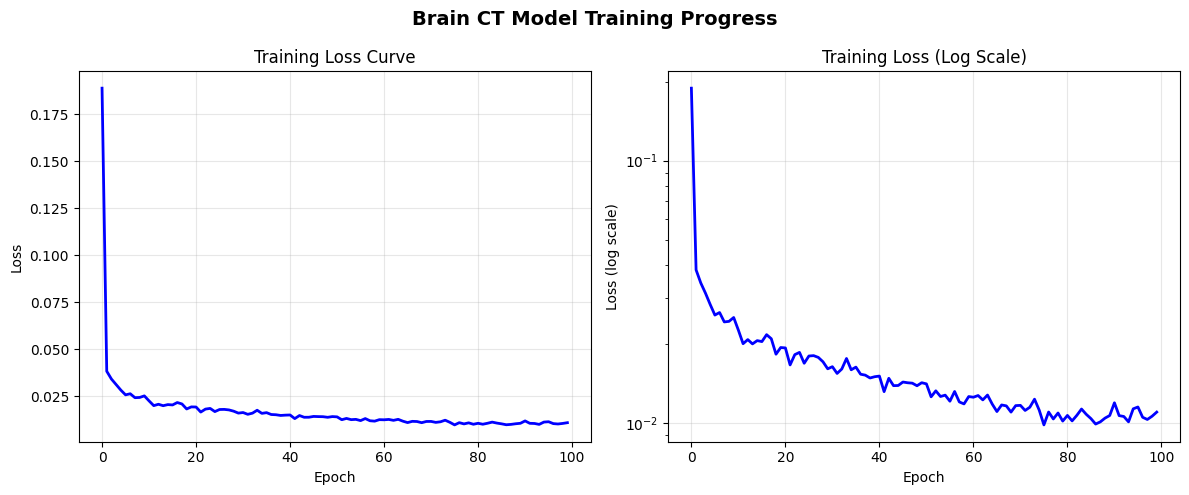

In [6]:
# ============================================
# TRAINING VISUALIZATION
# ============================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses, 'b-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(losses, 'b-', linewidth=2)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.title('Training Loss (Log Scale)')
plt.grid(True, alpha=0.3)

plt.suptitle('Brain CT Model Training Progress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Generating high-quality brain CT images...


Generating: 100%|██████████| 200/200 [00:06<00:00, 32.83it/s]


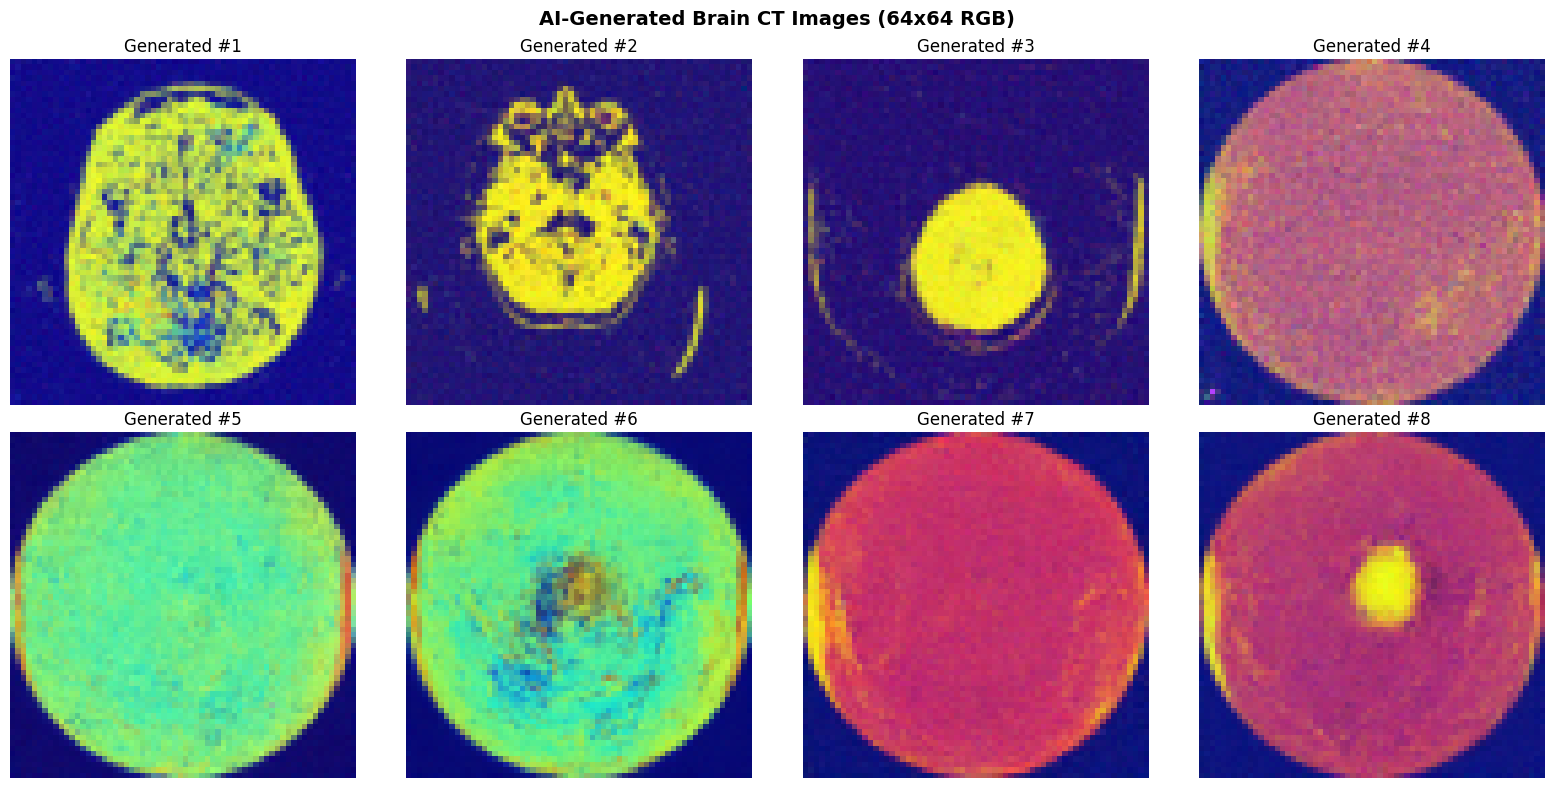


✅ Generation complete!


In [7]:
# ============================================
# FINAL GENERATION - HIGH QUALITY
# ============================================
print("Generating high-quality brain CT images...")

model.eval()
gen_scheduler = DDIMScheduler(
    num_train_timesteps=NUM_TRAIN_TIMESTEPS,
    schedule="linear_beta",
)
gen_scheduler.set_timesteps(200)

with torch.no_grad():
    noise = torch.randn(8, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
    image = noise
    
    for t in tqdm(gen_scheduler.timesteps, desc="Generating"):
        model_output = model(image, timesteps=torch.tensor([t] * 8).to(device))
        image, _ = gen_scheduler.step(model_output, t, image)
    
    final_images = image.cpu()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    img = final_images[i].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Generated #{i+1}')

plt.suptitle('AI-Generated Brain CT Images (64x64 RGB)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ Generation complete!")


📝 Prompt: 'brain with tumor in left hemisphere'
⚠️  Note: Model doesn't understand text - prompt is used as random seed


Generating: 100%|███████████████████| 150/150 [00:03<00:00, 44.88it/s]


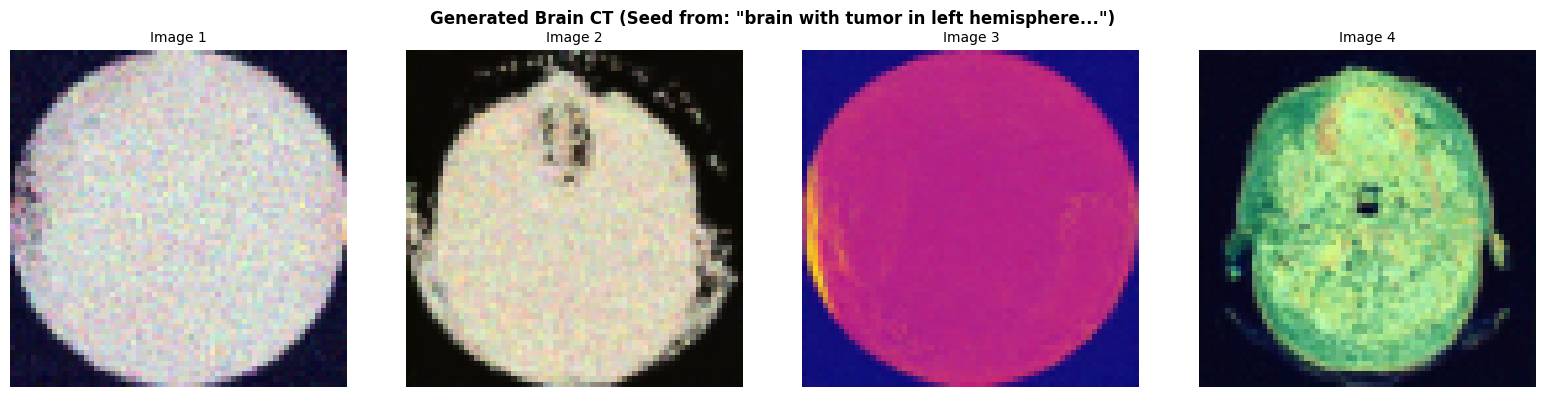

: 

In [ ]:
# ============================================
# DEMO: "Prompt-based" Generation
# ============================================
# NOTE: This model is trained UNCONDITIONALLY - it doesn't understand text prompts!
# The prompt is only used as a SEED for reproducibility.
# Different prompts = different random variations, but no semantic control.

def generate_from_prompt(prompt, num_images=4, quality_steps=200):
    """
    Generate brain CT images. The prompt acts as a random seed, not semantic guidance.
    """
    print(f"\n{'='*60}")
    print(f"📝 Prompt: '{prompt}'")
    print(f"⚠️  Note: Model doesn't understand text - prompt is used as random seed")
    print(f"{'='*60}")
    
    # Use prompt hash as seed for reproducibility
    seed = hash(prompt) % (2**32)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
    
    model.eval()
    gen_scheduler = DDIMScheduler(
        num_train_timesteps=NUM_TRAIN_TIMESTEPS,
        schedule="linear_beta",
    )
    gen_scheduler.set_timesteps(quality_steps)
    
    with torch.no_grad():
        noise = torch.randn(num_images, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
        image = noise
        
        for t in tqdm(gen_scheduler.timesteps, desc="Generating", ncols=70):
            model_output = model(image, timesteps=torch.tensor([t] * num_images).to(device))
            image, _ = gen_scheduler.step(model_output, t, image)
        
        generated = image.cpu()
    
    # Display
    fig, axes = plt.subplots(1, num_images, figsize=(4*num_images, 4))
    if num_images == 1:
        axes = [axes]
    
    for i, ax in enumerate(axes):
        img = generated[i].permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f'Image {i+1}', fontsize=10)
    
    plt.suptitle(f'Generated Brain CT (Seed from: "{prompt[:40]}...")', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return generated

# Example: Generate with different "prompts"
# (Remember: same prompt = same output, different prompt = different random variation)
YOUR_PROMPT = "brain with tumor in left hemisphere"
generated_images = generate_from_prompt(YOUR_PROMPT, num_images=4, quality_steps=150)